PEGASUS


In [14]:
# ⬇️ INSTALL DEPENDENCIES
!pip install git+https://github.com/openai/whisper.git
!pip install yt_dlp python-pptx nltk scikit-learn rouge-score transformers
!sudo apt update && sudo apt install -y ffmpeg

# 📚 IMPORTS
import whisper, nltk
nltk.download('punkt')
from pptx import Presentation
from pptx.util import Inches, Pt
from pptx.enum.text import PP_ALIGN
from pptx.dml.color import RGBColor
from pptx.chart.data import CategoryChartData
from pptx.enum.chart import XL_CHART_TYPE
from sklearn.metrics import precision_score, recall_score, f1_score
from rouge_score import rouge_scorer
from transformers import pipeline
import yt_dlp
import os

# 🎥 Download from YouTube
def download_youtube_video(url, output_path="downloaded_video.mp4"):
    ydl_opts = {
        'format': 'bestvideo[ext=mp4]+bestaudio[ext=m4a]/mp4',
        'outtmpl': output_path,
        'merge_output_format': 'mp4',
        'quiet': True
    }

    with yt_dlp.YoutubeDL(ydl_opts) as ydl:
        ydl.download([url])

    return output_path

# 🎙️ Transcription
def extract_transcript(video_path):
    model = whisper.load_model("base", device="cpu")
    result = model.transcribe(video_path)
    return result["text"]

# 📄 Summarization
def get_summarizer(model_name):
    return pipeline("summarization", model=model_name)

def create_phrased_summary(transcript, summarizer, max_chunk=1024):
    words = transcript.split()
    chunks = [" ".join(words[i:i + max_chunk]) for i in range(0, len(words), max_chunk)]

    summaries = []
    for chunk in chunks:
        summary = summarizer(chunk, max_length=150, min_length=30, do_sample=False)[0]['summary_text']
        summaries.append(summary)

    sentences = []
    for s in summaries:
        sentences.extend(nltk.sent_tokenize(s))
    return sentences

# 📈 Evaluate with ROUGE
def evaluate_summary_quality(generated_phrases, reference_text):
    generated_summary = " ".join(generated_phrases)
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=True)
    scores = scorer.score(reference_text, generated_summary)
    return scores

# ✨ Extract keywords
def extract_keywords(sentence):
    words = sentence.split()
    keywords = [word for word in words if len(word) > 4]
    return keywords[:3]

# 📊 Create PPT with chart
def create_ppt(summary_phrases, ppt_path, metrics):
    prs = Presentation()
    points_per_slide = 3
    max_slides = 8
    for i in range(0, min(len(summary_phrases), max_slides * points_per_slide), points_per_slide):
        slide = prs.slides.add_slide(prs.slide_layouts[5])
        title = slide.shapes.add_textbox(Inches(1), Inches(0.3), Inches(8), Inches(1))
        title_frame = title.text_frame
        title_frame.text = f"Key Takeaways - Slide {i//points_per_slide + 1}"
        title_frame.paragraphs[0].font.size = Pt(44)
        title_frame.paragraphs[0].font.bold = True
        title_frame.paragraphs[0].font.color.rgb = RGBColor(0, 102, 204)
        title_frame.paragraphs[0].alignment = PP_ALIGN.CENTER

        content = slide.shapes.add_textbox(Inches(1), Inches(1.5), Inches(8), Inches(5))
        content_frame = content.text_frame
        content_frame.word_wrap = True

        for point in summary_phrases[i:i+points_per_slide]:
            p = content_frame.add_paragraph()
            keywords = extract_keywords(point)
            run = p.add_run()
            run.text = "• "
            run.font.size = Pt(32)
            run.font.bold = True
            run.font.color.rgb = RGBColor(50, 50, 50)

            for word in point.split():
                run = p.add_run()
                run.text = f"{word} "
                run.font.size = Pt(32)
                run.font.name = "Arial"
                run.font.color.rgb = RGBColor(0, 128, 0) if word in keywords else RGBColor(50, 50, 50)
            p.space_after = Pt(12)

    # 📈 Chart slide
    chart_slide = prs.slides.add_slide(prs.slide_layouts[5])
    title = chart_slide.shapes.add_textbox(Inches(1), Inches(0.3), Inches(8), Inches(1))
    title.text_frame.text = "Summary Evaluation Metrics"

    chart_data = CategoryChartData()
    chart_data.categories = ['ROUGE-1', 'ROUGE-L']
    chart_data.add_series('Precision', [metrics['rouge1'].precision, metrics['rougeL'].precision])
    chart_data.add_series('Recall', [metrics['rouge1'].recall, metrics['rougeL'].recall])
    chart_data.add_series('F1', [metrics['rouge1'].fmeasure, metrics['rougeL'].fmeasure])

    x, y, cx, cy = Inches(1), Inches(1.5), Inches(8), Inches(4.5)
    chart = chart_slide.shapes.add_chart(XL_CHART_TYPE.COLUMN_CLUSTERED, x, y, cx, cy, chart_data).chart

    prs.save(ppt_path)

# 🚀 MAIN LOGIC
video_url = input("📽️ Enter YouTube video URL: ").strip()
summarizer_choice = input("🧠 Choose summarizer (bart | t5 | pegasus): ").strip().lower()

model_map = {
    "bart": "facebook/bart-large-cnn",
    "t5": "t5-base",
    "pegasus": "google/pegasus-xsum"
}
model_name = model_map.get(summarizer_choice, "facebook/bart-large-cnn")

ppt_path = f"summary_{summarizer_choice}.pptx"
video_path = download_youtube_video(video_url)

print("🎙️ Transcribing video...")
transcript = extract_transcript(video_path)

print(f"🧠 Summarizing using {model_name}...")
summarizer = get_summarizer(model_name)
phrases = create_phrased_summary(transcript, summarizer)

print("📈 Evaluating summary...")
reference_summary = " ".join(nltk.sent_tokenize(transcript)[:5])
metrics = evaluate_summary_quality(phrases, reference_summary)

print("📊 Creating PowerPoint...")
create_ppt(phrases, ppt_path, metrics)

# ✅ DONE
print(f"\n✅ PPT saved as {ppt_path}")
print("\n📋 Evaluation Metrics:")
for k, v in metrics.items():
    print(f"{k.upper()}: Precision={v.precision:.4f}, Recall={v.recall:.4f}, F1={v.fmeasure:.4f}")


  Cloning https://github.com/openai/whisper.git to /tmp/pip-req-build-jqephcuv
  Running command git clone --filter=blob:none --quiet https://github.com/openai/whisper.git /tmp/pip-req-build-jqephcuv
  Resolved https://github.com/openai/whisper.git to commit 517a43ecd132a2089d85f4ebc044728a71d49f6e
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:5 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:6 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


📽️ Enter YouTube video URL: https://www.youtube.com/watch?v=LYVwbB2-tnE&t=7s
🧠 Choose summarizer (bart | t5 | pegasus): pegasus
🎙️ Transcribing video...


/usr/local/lib/python3.11/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


🧠 Summarizing using google/pegasus-xsum...


...

spiece.model:   0%|          | 0.00/1.91M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.52M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/65.0 [00:00<?, ?B/s]

Device set to use cpu


📈 Evaluating summary...
📊 Creating PowerPoint...

✅ PPT saved as summary_pegasus.pptx

📋 Evaluation Metrics:
ROUGE1: Precision=0.6552, Recall=0.2568, F1=0.3689
ROUGEL: Precision=0.4828, Recall=0.1892, F1=0.2718


BART

In [15]:
# ⬇️ INSTALL DEPENDENCIES
!pip install git+https://github.com/openai/whisper.git
!pip install yt_dlp python-pptx nltk scikit-learn rouge-score transformers
!sudo apt update && sudo apt install -y ffmpeg

# 📚 IMPORTS
import whisper, nltk
nltk.download('punkt')
from pptx import Presentation
from pptx.util import Inches, Pt
from pptx.enum.text import PP_ALIGN
from pptx.dml.color import RGBColor
from pptx.chart.data import CategoryChartData
from pptx.enum.chart import XL_CHART_TYPE
from sklearn.metrics import precision_score, recall_score, f1_score
from rouge_score import rouge_scorer
from transformers import pipeline
import yt_dlp
import os

# 🎥 Download from YouTube
def download_youtube_video(url, output_path="downloaded_video.mp4"):
    ydl_opts = {
        'format': 'bestvideo[ext=mp4]+bestaudio[ext=m4a]/mp4',
        'outtmpl': output_path,
        'merge_output_format': 'mp4',
        'quiet': True
    }

    with yt_dlp.YoutubeDL(ydl_opts) as ydl:
        ydl.download([url])

    return output_path

# 🎙️ Transcription
def extract_transcript(video_path):
    model = whisper.load_model("base", device="cpu")
    result = model.transcribe(video_path)
    return result["text"]

# 📄 Summarization
def get_summarizer(model_name):
    return pipeline("summarization", model=model_name)

def create_phrased_summary(transcript, summarizer, max_chunk=1024):
    words = transcript.split()
    chunks = [" ".join(words[i:i + max_chunk]) for i in range(0, len(words), max_chunk)]

    summaries = []
    for chunk in chunks:
        summary = summarizer(chunk, max_length=150, min_length=30, do_sample=False)[0]['summary_text']
        summaries.append(summary)

    sentences = []
    for s in summaries:
        sentences.extend(nltk.sent_tokenize(s))
    return sentences

# 📈 Evaluate with ROUGE
def evaluate_summary_quality(generated_phrases, reference_text):
    generated_summary = " ".join(generated_phrases)
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=True)
    scores = scorer.score(reference_text, generated_summary)
    return scores

# ✨ Extract keywords
def extract_keywords(sentence):
    words = sentence.split()
    keywords = [word for word in words if len(word) > 4]
    return keywords[:3]

# 📊 Create PPT with chart
def create_ppt(summary_phrases, ppt_path, metrics):
    prs = Presentation()
    points_per_slide = 3
    max_slides = 8
    for i in range(0, min(len(summary_phrases), max_slides * points_per_slide), points_per_slide):
        slide = prs.slides.add_slide(prs.slide_layouts[5])
        title = slide.shapes.add_textbox(Inches(1), Inches(0.3), Inches(8), Inches(1))
        title_frame = title.text_frame
        title_frame.text = f"Key Takeaways - Slide {i//points_per_slide + 1}"
        title_frame.paragraphs[0].font.size = Pt(44)
        title_frame.paragraphs[0].font.bold = True
        title_frame.paragraphs[0].font.color.rgb = RGBColor(0, 102, 204)
        title_frame.paragraphs[0].alignment = PP_ALIGN.CENTER

        content = slide.shapes.add_textbox(Inches(1), Inches(1.5), Inches(8), Inches(5))
        content_frame = content.text_frame
        content_frame.word_wrap = True

        for point in summary_phrases[i:i+points_per_slide]:
            p = content_frame.add_paragraph()
            keywords = extract_keywords(point)
            run = p.add_run()
            run.text = "• "
            run.font.size = Pt(32)
            run.font.bold = True
            run.font.color.rgb = RGBColor(50, 50, 50)

            for word in point.split():
                run = p.add_run()
                run.text = f"{word} "
                run.font.size = Pt(32)
                run.font.name = "Arial"
                run.font.color.rgb = RGBColor(0, 128, 0) if word in keywords else RGBColor(50, 50, 50)
            p.space_after = Pt(12)

    # 📈 Chart slide
    chart_slide = prs.slides.add_slide(prs.slide_layouts[5])
    title = chart_slide.shapes.add_textbox(Inches(1), Inches(0.3), Inches(8), Inches(1))
    title.text_frame.text = "Summary Evaluation Metrics"

    chart_data = CategoryChartData()
    chart_data.categories = ['ROUGE-1', 'ROUGE-L']
    chart_data.add_series('Precision', [metrics['rouge1'].precision, metrics['rougeL'].precision])
    chart_data.add_series('Recall', [metrics['rouge1'].recall, metrics['rougeL'].recall])
    chart_data.add_series('F1', [metrics['rouge1'].fmeasure, metrics['rougeL'].fmeasure])

    x, y, cx, cy = Inches(1), Inches(1.5), Inches(8), Inches(4.5)
    chart = chart_slide.shapes.add_chart(XL_CHART_TYPE.COLUMN_CLUSTERED, x, y, cx, cy, chart_data).chart

    prs.save(ppt_path)

# 🚀 MAIN LOGIC
video_url = input("📽️ Enter YouTube video URL: ").strip()
summarizer_choice = input("🧠 Choose summarizer (bart | t5 | pegasus): ").strip().lower()

model_map = {
    "bart": "facebook/bart-large-cnn",
    "t5": "t5-base",
    "pegasus": "google/pegasus-xsum"
}
model_name = model_map.get(summarizer_choice, "facebook/bart-large-cnn")

ppt_path = f"summary_{summarizer_choice}.pptx"
video_path = download_youtube_video(video_url)

print("🎙️ Transcribing video...")
transcript = extract_transcript(video_path)

print(f"🧠 Summarizing using {model_name}...")
summarizer = get_summarizer(model_name)
phrases = create_phrased_summary(transcript, summarizer)

print("📈 Evaluating summary...")
reference_summary = " ".join(nltk.sent_tokenize(transcript)[:5])
metrics = evaluate_summary_quality(phrases, reference_summary)

print("📊 Creating PowerPoint...")
create_ppt(phrases, ppt_path, metrics)

# ✅ DONE
print(f"\n✅ PPT saved as {ppt_path}")
print("\n📋 Evaluation Metrics:")
for k, v in metrics.items():
    print(f"{k.upper()}: Precision={v.precision:.4f}, Recall={v.recall:.4f}, F1={v.fmeasure:.4f}")


  Cloning https://github.com/openai/whisper.git to /tmp/pip-req-build-8hfw5lb_
  Running command git clone --filter=blob:none --quiet https://github.com/openai/whisper.git /tmp/pip-req-build-8hfw5lb_
  Resolved https://github.com/openai/whisper.git to commit 517a43ecd132a2089d85f4ebc044728a71d49f6e
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Hit:1 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


📽️ Enter YouTube video URL: https://www.youtube.com/watch?v=LYVwbB2-tnE&t=7s
🧠 Choose summarizer (bart | t5 | pegasus): bart
🎙️ Transcribing video...


/usr/local/lib/python3.11/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


🧠 Summarizing using facebook/bart-large-cnn...


Device set to use cpu


📈 Evaluating summary...
📊 Creating PowerPoint...

✅ PPT saved as summary_bart.pptx

📋 Evaluation Metrics:
ROUGE1: Precision=0.5614, Recall=0.4324, F1=0.4885
ROUGEL: Precision=0.4737, Recall=0.3649, F1=0.4122


T5

In [18]:
# ⬇️ INSTALL DEPENDENCIES
!pip install git+https://github.com/openai/whisper.git
!pip install yt_dlp python-pptx nltk scikit-learn rouge-score transformers sumy
!sudo apt update && sudo apt install -y ffmpeg

# 📚 IMPORTS
import whisper
import nltk
nltk.download('punkt')
from pptx import Presentation
from pptx.util import Inches, Pt
from pptx.enum.text import PP_ALIGN
from pptx.dml.color import RGBColor
from pptx.chart.data import CategoryChartData
from pptx.enum.chart import XL_CHART_TYPE
from rouge_score import rouge_scorer
from transformers import pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sumy.parsers.plaintext import PlaintextParser
from sumy.nlp.tokenizers import Tokenizer
from sumy.summarizers.lex_rank import LexRankSummarizer
import yt_dlp
import numpy as np
from collections import defaultdict
import os

# 🎥 YouTube Downloader
def download_youtube_video(url, output_path="downloaded_video.mp4"):
    ydl_opts = {
        'format': 'bestvideo[ext=mp4]+bestaudio[ext=m4a]/mp4',
        'outtmpl': output_path,
        'merge_output_format': 'mp4',
        'quiet': True
    }
    with yt_dlp.YoutubeDL(ydl_opts) as ydl:
        ydl.download([url])
    return output_path

# 🎙️ Transcription
def extract_transcript(video_path):
    model = whisper.load_model("base", device="cpu")
    result = model.transcribe(video_path)
    return result["text"]

# 📄 Summarization Models
class HybridSummarizer:
    def __init__(self):
        self.models = {
            "bart": "facebook/bart-large-cnn",
            "t5": "t5-base",
            "pegasus": "google/pegasus-xsum"
        }
        self.summarizers = {
            name: pipeline("summarization", model=model_name)
            for name, model_name in self.models.items()
        }
        self.lexrank = LexRankSummarizer()

    def _chunk_text(self, text, max_chunk=1024):
        words = text.split()
        return [" ".join(words[i:i + max_chunk]) for i in range(0, len(words), max_chunk)]

    def _summarize_with_model(self, text, model_name, max_length=150):
        chunks = self._chunk_text(text)
        summaries = []
        for chunk in chunks:
            summary = self.summarizers[model_name](
                chunk,
                max_length=max_length,
                min_length=30,
                do_sample=False
            )[0]['summary_text']
            summaries.append(summary)
        return " ".join(summaries)

    def _summarize_with_lexrank(self, text, sentences_count=5):
        parser = PlaintextParser.from_string(text, Tokenizer("english"))
        summary = self.lexrank(parser.document, sentences_count)
        return " ".join([str(sentence) for sentence in summary])

    def get_hybrid_summary(self, text, max_length=150):
        # Generate summaries from all models
        summaries = {}
        for model_name in self.models:
            try:
                summaries[model_name] = self._summarize_with_model(text, model_name, max_length)
            except Exception as e:
                print(f"⚠️ {model_name} failed, using LexRank as fallback: {e}")
                summaries[model_name] = self._summarize_with_lexrank(text)

        # Combine using TF-IDF similarity scoring
        all_sentences = []
        for model_name, summary in summaries.items():
            all_sentences.extend(nltk.sent_tokenize(summary))

        # Remove duplicates
        unique_sentences = []
        seen = set()
        for s in all_sentences:
            clean_s = s.strip()
            if clean_s not in seen:
                unique_sentences.append(clean_s)
                seen.add(clean_s)

        if not unique_sentences:
            return "No summary could be generated", summaries

        # Score sentences by relevance to original text
        vectorizer = TfidfVectorizer().fit([text] + unique_sentences)
        text_vec = vectorizer.transform([text])
        scores = []

        for s in unique_sentences:
            s_vec = vectorizer.transform([s])
            # Fixed: Use toarray() instead of .A
            sim = np.dot(s_vec.toarray(), text_vec.T.toarray())[0][0]
            scores.append(sim)

        # Get top sentences by score
        top_indices = np.argsort(scores)[::-1][:max_length//20]  # Adjust for desired length
        hybrid_summary = " ".join([unique_sentences[i] for i in top_indices])

        return hybrid_summary, summaries

# 📈 Evaluation
class SummaryEvaluator:
    def __init__(self):
        self.scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

    def evaluate(self, generated_summary, reference_text):
        return self.scorer.score(reference_text, generated_summary)

    def compare_models(self, summaries, reference_text):
        results = {}
        for model_name, summary in summaries.items():
            results[model_name] = self.evaluate(summary, reference_text)
        return results

# ✨ Content Processing
def extract_key_phrases(summary, max_phrases=15):
    sentences = nltk.sent_tokenize(summary)
    return sentences[:max_phrases]

def extract_keywords(sentence, min_length=4):
    words = [word.lower() for word in sentence.split() if word.isalpha()]
    return [word for word in words if len(word) >= min_length][:3]

# 📊 PPT Creation
class PPTCreator:
    def __init__(self):
        self.theme_colors = {
            "title": RGBColor(0, 102, 204),
            "text": RGBColor(50, 50, 50),
            "highlight": RGBColor(0, 128, 0),
            "accent": RGBColor(204, 0, 0)
        }

    def create_slide(self, prs, title_text, content_items, slide_type=5):
        slide = prs.slides.add_slide(prs.slide_layouts[slide_type])

        # Add title
        title = slide.shapes.add_textbox(Inches(1), Inches(0.3), Inches(8), Inches(1))
        title_frame = title.text_frame
        title_frame.text = title_text
        title_frame.paragraphs[0].font.size = Pt(44)
        title_frame.paragraphs[0].font.bold = True
        title_frame.paragraphs[0].font.color.rgb = self.theme_colors["title"]
        title_frame.paragraphs[0].alignment = PP_ALIGN.CENTER

        # Add content
        content = slide.shapes.add_textbox(Inches(1), Inches(1.5), Inches(8), Inches(5))
        content_frame = content.text_frame
        content_frame.word_wrap = True

        for item in content_items:
            p = content_frame.add_paragraph()
            run = p.add_run()
            run.text = "• "
            run.font.size = Pt(32)
            run.font.bold = True
            run.font.color.rgb = self.theme_colors["text"]

            keywords = extract_keywords(item)
            for word in item.split():
                run = p.add_run()
                run.text = f"{word} "
                run.font.size = Pt(32)
                run.font.name = "Arial"
                if word.lower() in keywords:
                    run.font.color.rgb = self.theme_colors["highlight"]
                    run.font.bold = True
                else:
                    run.font.color.rgb = self.theme_colors["text"]
            p.space_after = Pt(12)

        return slide

    def create_metrics_slide(self, prs, metrics, model_comparisons):
        slide = prs.slides.add_slide(prs.slide_layouts[5])

        # Title
        title = slide.shapes.add_textbox(Inches(1), Inches(0.3), Inches(8), Inches(1))
        title.text_frame.text = "Summary Evaluation Metrics"

        # Hybrid metrics chart
        chart_data = CategoryChartData()
        chart_data.categories = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']

        for metric in ['precision', 'recall', 'fmeasure']:
            values = [
                getattr(metrics['rouge1'], metric),
                getattr(metrics['rouge2'], metric),
                getattr(metrics['rougeL'], metric)
            ]
            chart_data.add_series(metric.capitalize(), values)

        x, y, cx, cy = Inches(1), Inches(1.5), Inches(8), Inches(4.5)
        chart = slide.shapes.add_chart(
            XL_CHART_TYPE.COLUMN_CLUSTERED, x, y, cx, cy, chart_data
        ).chart

        # Add model comparison table
        table = slide.shapes.add_table(
            len(model_comparisons)+1, 4, Inches(1), Inches(2.5), Inches(8), Inches(2)
        ).table

        # Header row
        for col, header in enumerate(["Model", "ROUGE-1 F1", "ROUGE-2 F1", "ROUGE-L F1"]):
            cell = table.cell(0, col)
            cell.text = header
            cell.fill.solid()
            cell.fill.fore_color.rgb = self.theme_colors["title"]
            cell.text_frame.paragraphs[0].font.color.rgb = RGBColor(255, 255, 255)

        # Data rows
        for row, (model_name, scores) in enumerate(model_comparisons.items(), 1):
            table.cell(row, 0).text = model_name.upper()
            table.cell(row, 1).text = f"{scores['rouge1'].fmeasure:.3f}"
            table.cell(row, 2).text = f"{scores['rouge2'].fmeasure:.3f}"
            table.cell(row, 3).text = f"{scores['rougeL'].fmeasure:.3f}"

        return slide

    def create_presentation(self, title, key_phrases, metrics, model_comparisons, output_path):
        prs = Presentation()

        # Title slide
        self.create_slide(prs, title, [], 0)

        # Content slides
        points_per_slide = 3
        for i in range(0, len(key_phrases), points_per_slide):
            slide_title = f"Key Insights - Part {i//points_per_slide + 1}"
            self.create_slide(prs, slide_title, key_phrases[i:i+points_per_slide])

        # Metrics slide
        self.create_metrics_slide(prs, metrics, model_comparisons)

        prs.save(output_path)
        return output_path

# 🚀 MAIN PIPELINE
def youtube_to_ppt_pipeline(youtube_url, output_path="hybrid_summary.pptx"):
    print("🚀 Starting YouTube to PPT Pipeline with Hybrid Summarization")

    # Step 1: Download video
    print("📥 Downloading YouTube video...")
    video_path = download_youtube_video(youtube_url)

    # Step 2: Transcribe audio
    print("🎙️ Transcribing video content...")
    transcript = extract_transcript(video_path)
    if not transcript:
        raise ValueError("Failed to transcribe video content")

    # Step 3: Generate reference summary (first 5 sentences)
    reference_summary = " ".join(nltk.sent_tokenize(transcript)[:5])

    # Step 4: Hybrid summarization
    print("🧠 Generating hybrid summary...")
    summarizer = HybridSummarizer()
    hybrid_summary, model_summaries = summarizer.get_hybrid_summary(transcript)

    # Step 5: Evaluate summaries
    print("📊 Evaluating summaries...")
    evaluator = SummaryEvaluator()
    hybrid_metrics = evaluator.evaluate(hybrid_summary, reference_summary)
    model_comparisons = evaluator.compare_models(model_summaries, reference_summary)

    # Step 6: Prepare presentation content
    print("🖌️ Preparing presentation content...")
    key_phrases = extract_key_phrases(hybrid_summary)

    # Step 7: Create PowerPoint
    print("📊 Creating PowerPoint presentation...")
    ppt_creator = PPTCreator()
    video_title = "Video Summary"  # Could extract from YouTube
    ppt_path = ppt_creator.create_presentation(
        video_title, key_phrases, hybrid_metrics, model_comparisons, output_path
    )

    # Clean up
    if os.path.exists(video_path):
        os.remove(video_path)

    print("\n✅ Pipeline completed successfully!")
    print(f"📄 Hybrid Summary (ROUGE-L F1: {hybrid_metrics['rougeL'].fmeasure:.3f})")
    print(f"📊 Presentation saved to: {os.path.abspath(ppt_path)}")

    return {
        "ppt_path": ppt_path,
        "hybrid_metrics": hybrid_metrics,
        "model_comparisons": model_comparisons
    }

# 🏃‍♂️ RUN THE PIPELINE
if __name__ == "__main__":
    youtube_url = input("📽️ Enter YouTube video URL: ").strip()
    result = youtube_to_ppt_pipeline(youtube_url)

    # Print evaluation results
    print("\n📋 Evaluation Results:")
    print(f"Hybrid ROUGE-1 F1: {result['hybrid_metrics']['rouge1'].fmeasure:.4f}")
    print(f"Hybrid ROUGE-L F1: {result['hybrid_metrics']['rougeL'].fmeasure:.4f}")

    print("\n🔍 Model Comparisons:")
    for model, scores in result['model_comparisons'].items():
        print(f"{model.upper():<8} ROUGE-L F1: {scores['rougeL'].fmeasure:.4f}")

  Cloning https://github.com/openai/whisper.git to /tmp/pip-req-build-ectrw5fn
  Running command git clone --filter=blob:none --quiet https://github.com/openai/whisper.git /tmp/pip-req-build-ectrw5fn
  Resolved https://github.com/openai/whisper.git to commit 517a43ecd132a2089d85f4ebc044728a71d49f6e
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Hit:1 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


📽️ Enter YouTube video URL: https://www.youtube.com/watch?v=LYVwbB2-tnE&t=7s
🚀 Starting YouTube to PPT Pipeline with Hybrid Summarization
📥 Downloading YouTube video...
🎙️ Transcribing video content...


/usr/local/lib/python3.11/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


🧠 Generating hybrid summary...


Device set to use cpu
Device set to use cpu
Some weights of PegasusForConditionalGeneration were not initialized from the model checkpoint at google/pegasus-xsum and are newly initialized: ['model.decoder.embed_positions.weight', 'model.encoder.embed_positions.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Device set to use cpu


📊 Evaluating summaries...
🖌️ Preparing presentation content...
📊 Creating PowerPoint presentation...

✅ Pipeline completed successfully!
📄 Hybrid Summary (ROUGE-L F1: 0.376)
📊 Presentation saved to: /content/hybrid_summary.pptx

📋 Evaluation Results:
Hybrid ROUGE-1 F1: 0.6118
Hybrid ROUGE-L F1: 0.3765

🔍 Model Comparisons:
BART     ROUGE-L F1: 0.4122
T5       ROUGE-L F1: 0.3818
PEGASUS  ROUGE-L F1: 0.2718


  Cloning https://github.com/openai/whisper.git to /tmp/pip-req-build-5eu385es
  Running command git clone --filter=blob:none --quiet https://github.com/openai/whisper.git /tmp/pip-req-build-5eu385es
  Resolved https://github.com/openai/whisper.git to commit 517a43ecd132a2089d85f4ebc044728a71d49f6e
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:2 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:3 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:5 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRele

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


📽️ Enter YouTube video URL: https://www.youtube.com/watch?v=LYVwbB2-tnE&t=7s

🚀 Starting evaluation pipeline...
📥 Downloading video...
🎙️ Transcribing audio...


/usr/local/lib/python3.11/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")



🧠 Evaluating models...


Device set to use cpu
Device set to use cpu
Some weights of PegasusForConditionalGeneration were not initialized from the model checkpoint at google/pegasus-xsum and are newly initialized: ['model.decoder.embed_positions.weight', 'model.encoder.embed_positions.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Device set to use cpu


⚙️ Evaluating BART...
⚙️ Evaluating T5...
⚙️ Evaluating Pegasus...
⚙️ Evaluating Summa...

📊 Generating visualizations...
✅ Saved visualization to model_comparison.png


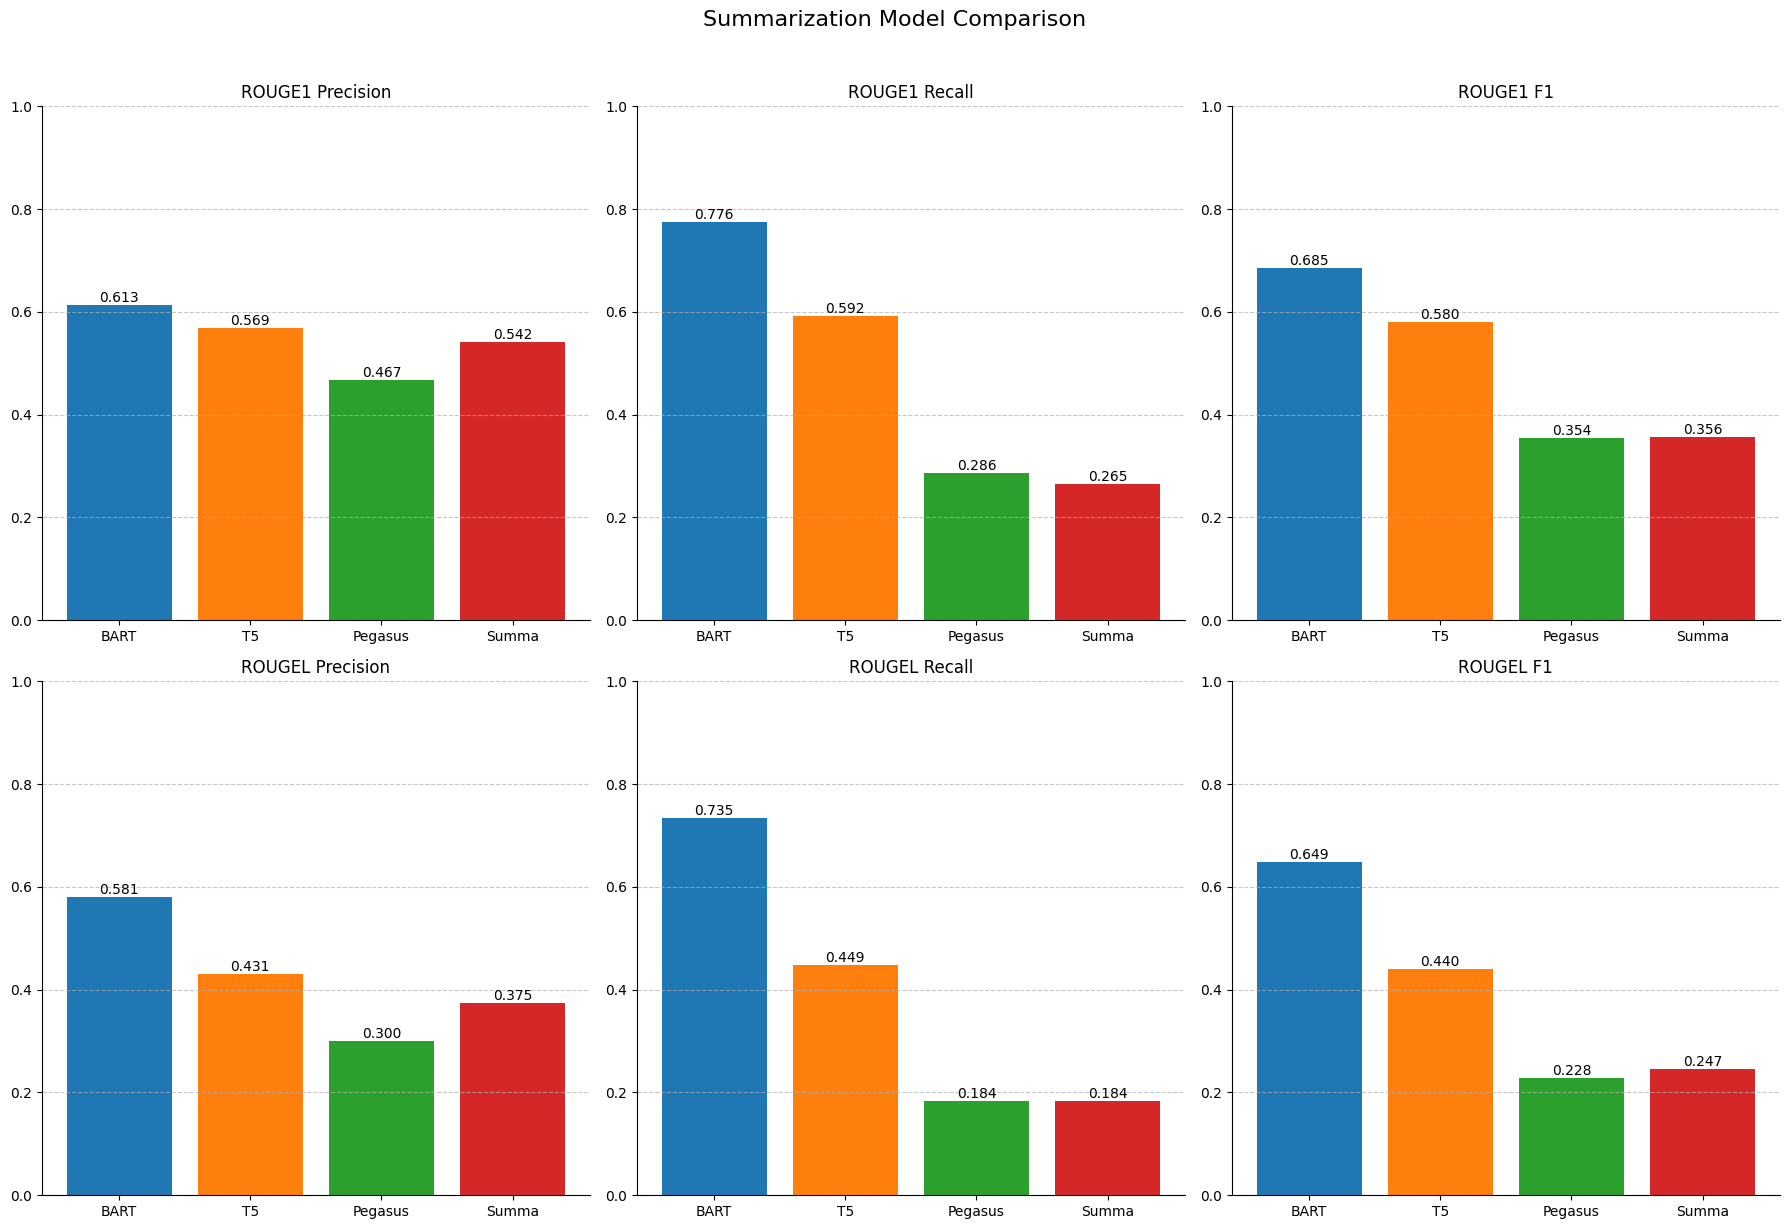

✅ Saved comparison table to model_comparison.pptx

🎉 Evaluation complete! Results saved to:
- model_comparison.png (visualization)
- model_comparison.pptx (table)


In [24]:
# ⬇️ INSTALL DEPENDENCIES
!pip install git+https://github.com/openai/whisper.git
!pip install yt_dlp python-pptx nltk scikit-learn rouge-score transformers sumy summa matplotlib
!sudo apt update && sudo apt install -y ffmpeg

# 📚 IMPORTS
import whisper
import nltk
nltk.download('punkt')
from pptx import Presentation
from pptx.util import Inches, Pt
from pptx.enum.text import PP_ALIGN
from pptx.dml.color import RGBColor
from rouge_score import rouge_scorer
from transformers import pipeline
from sumy.parsers.plaintext import PlaintextParser
from sumy.nlp.tokenizers import Tokenizer
from sumy.summarizers.lex_rank import LexRankSummarizer
from summa import summarizer as summa_summarizer
import yt_dlp
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib import rcParams

# Set style for matplotlib
rcParams['figure.figsize'] = (12, 8)
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False

# 🎥 YouTube Downloader
def download_youtube_video(url, output_path="downloaded_video.mp4"):
    ydl_opts = {
        'format': 'bestvideo[ext=mp4]+bestaudio[ext=m4a]/mp4',
        'outtmpl': output_path,
        'merge_output_format': 'mp4',
        'quiet': True
    }
    with yt_dlp.YoutubeDL(ydl_opts) as ydl:
        ydl.download([url])
    return output_path

# 🎙️ Transcription
def extract_transcript(video_path):
    model = whisper.load_model("base", device="cpu")
    result = model.transcribe(video_path)
    return result["text"]

class SummarizationEvaluator:
    def __init__(self):
        self.models = {
            "BART": pipeline("summarization", model="facebook/bart-large-cnn"),
            "T5": pipeline("summarization", model="t5-base"),
            "Pegasus": pipeline("summarization", model="google/pegasus-xsum"),
            "Summa": None  # Special case for Summa
        }
        self.scorer = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=True)

    def summarize(self, text, model_name, max_length=150):
        if model_name == "Summa":
            return summa_summarizer.summarize(text, ratio=0.2)
        else:
            chunks = self._chunk_text(text)
            summaries = []
            for chunk in chunks:
                summary = self.models[model_name](
                    chunk,
                    max_length=max_length,
                    min_length=30,
                    do_sample=False
                )[0]['summary_text']
                summaries.append(summary)
            return " ".join(summaries)

    def _chunk_text(self, text, max_chunk=1024):
        words = text.split()
        return [" ".join(words[i:i + max_chunk]) for i in range(0, len(words), max_chunk)]

    def evaluate_all_models(self, transcript, reference_summary):
        results = {}
        for model_name in self.models:
            print(f"⚙️ Evaluating {model_name}...")
            summary = self.summarize(transcript, model_name)
            scores = self.scorer.score(reference_summary, summary)
            results[model_name] = {
                'rouge1': {
                    'precision': scores['rouge1'].precision,
                    'recall': scores['rouge1'].recall,
                    'f1': scores['rouge1'].fmeasure
                },
                'rougeL': {
                    'precision': scores['rougeL'].precision,
                    'recall': scores['rougeL'].recall,
                    'f1': scores['rougeL'].fmeasure
                }
            }
        return results

def visualize_metrics(metrics):
    """Generate matplotlib visualizations for all metrics"""
    models = list(metrics.keys())
    rouge_types = ['rouge1', 'rougeL']
    metric_types = ['precision', 'recall', 'f1']

    # Create figure with subplots
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Summarization Model Comparison', fontsize=16, y=1.02)

    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # Distinct colors

    for i, rouge in enumerate(rouge_types):
        for j, metric in enumerate(metric_types):
            ax = axes[i,j]
            values = [metrics[model][rouge][metric] for model in models]
            bars = ax.bar(models, values, color=colors)

            ax.set_title(f"{rouge.upper()} {metric.capitalize()}")
            ax.set_ylim(0, 1)
            ax.grid(axis='y', linestyle='--', alpha=0.7)

            # Add value labels on top of bars
            for bar in bars:
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height,
                        f'{height:.3f}',
                        ha='center', va='bottom')

    plt.tight_layout()
    plt.savefig('model_comparison.png', bbox_inches='tight', dpi=300)
    print("✅ Saved visualization to model_comparison.png")
    plt.show()

def create_comparison_table(metrics):
    """Create a PowerPoint slide with comparison table"""
    prs = Presentation()
    slide = prs.slides.add_slide(prs.slide_layouts[5])
    title = slide.shapes.title
    title.text = "Model Performance Comparison"

    # Create table
    rows = len(metrics) + 1
    cols = 7  # Model + (Precision, Recall, F1) x 2 metrics
    left, top, width, height = Inches(0.5), Inches(1.5), Inches(9), Inches(0.5)
    table = slide.shapes.add_table(rows, cols, left, top, width, height).table

    # Set column widths
    for i in range(cols):
        table.columns[i].width = Inches(1.2)

    # Header row
    headers = ["Model", "R1-P", "R1-R", "R1-F1", "RL-P", "RL-R", "RL-F1"]
    for i, header in enumerate(headers):
        cell = table.cell(0, i)
        cell.text = header
        cell.fill.solid()
        cell.fill.fore_color.rgb = RGBColor(0, 102, 204)
        cell.text_frame.paragraphs[0].font.color.rgb = RGBColor(255, 255, 255)

    # Data rows
    for row, (model, scores) in enumerate(metrics.items(), 1):
        table.cell(row, 0).text = model
        table.cell(row, 1).text = f"{scores['rouge1']['precision']:.3f}"
        table.cell(row, 2).text = f"{scores['rouge1']['recall']:.3f}"
        table.cell(row, 3).text = f"{scores['rouge1']['f1']:.3f}"
        table.cell(row, 4).text = f"{scores['rougeL']['precision']:.3f}"
        table.cell(row, 5).text = f"{scores['rougeL']['recall']:.3f}"
        table.cell(row, 6).text = f"{scores['rougeL']['f1']:.3f}"

    prs.save('model_comparison.pptx')
    print("✅ Saved comparison table to model_comparison.pptx")

# 🚀 MAIN PIPELINE
def main():
    youtube_url = input("📽️ Enter YouTube video URL: ").strip()

    print("\n🚀 Starting evaluation pipeline...")
    print("📥 Downloading video...")
    video_path = download_youtube_video(youtube_url)

    print("🎙️ Transcribing audio...")
    transcript = extract_transcript(video_path)
    sentences = nltk.sent_tokenize(transcript)
    reference_summary = " ".join(sentences[:max(5, len(sentences)//10)])

    print("\n🧠 Evaluating models...")
    evaluator = SummarizationEvaluator()
    metrics = evaluator.evaluate_all_models(transcript, reference_summary)

    print("\n📊 Generating visualizations...")
    visualize_metrics(metrics)
    create_comparison_table(metrics)

    # Clean up
    if os.path.exists(video_path):
        os.remove(video_path)

    print("\n🎉 Evaluation complete! Results saved to:")
    print("- model_comparison.png (visualization)")
    print("- model_comparison.pptx (table)")

if __name__ == "__main__":
    main()